# Lab Experiment: Data Collection
## Web Scraping and APIs

**Course:** Data science  Laboratory
**Class:** B.Tech
**Duration:** 2 hours

---

### Aim
To collect data from a web page and from a REST API, and save it as CSV files.

### Objectives
1. Extract data from an HTML page using **BeautifulSoup**
2. Extract a table using **pandas.read_html**
3. Collect data from a **REST API** and parse the JSON response
4. Save all collected data to CSV files

### Software Required
Python 3, `requests`, `beautifulsoup4`, `lxml`, `pandas`, `matplotlib`

### Theory

There are two ways to collect data from the internet:

| | Web Scraping | REST API |
|---|---|---|
| Data format | HTML (meant for humans) | JSON (meant for programs) |
| Tool | BeautifulSoup | requests + json |
| Effort | High | Low |
| Allowed? | Only if the site permits it | Yes, that is what it is for |

**Rule: if an API exists, use the API.** Scrape only when there is no API.

---
## Step 0: Setup

In [1]:
# Install if needed (uncomment the line below)
# !pip install requests beautifulsoup4 lxml pandas matplotlib
%pip install pandas numpy requests beautifulsoup4 lxml matplotlib
import io
import json
import requests
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
from pathlib import Path

# Folder to store collected data
DATA = Path("data")
DATA.mkdir(exist_ok=True)

print("Setup complete. Data will be saved in:", DATA.resolve())

Note: you may need to restart the kernel to use updated packages.
Setup complete. Data will be saved in: /Users/apple/Downloads/Lab-1/data


---
## Step 1: Rules Before Collecting Data

Before scraping any website, check these four things:

1. **Check `robots.txt`** — visit `https://website.com/robots.txt`. It says which pages
   crawlers may visit.
2. **Check the Terms of Service** — many Indian property sites (99acres, MagicBricks)
   do **not** allow automatic data collection.
3. **Go slow** — wait 1–2 seconds between requests. Do not send requests in a fast loop.
4. **Never collect personal data** — no names, phone numbers or email IDs.

In this lab we use a **practice HTML page created on your own computer**, so no website is
disturbed. The API we use (Open-Meteo) is free and openly allows this.

In [3]:
import ssl
import certifi
from urllib.robotparser import RobotFileParser

def can_scrape(url):
    rp = RobotFileParser()
    rp.set_url(url.split("/")[0] + "//" + url.split("/")[2] + "/robots.txt")
    try:
        # Build an SSL context using certifi's trusted certs
        ctx = ssl.create_default_context(cafile=certifi.where())
        # RobotFileParser doesn't let you pass a context directly,
        # so monkeypatch urlopen via urllib.request instead:
        import urllib.request
        req = urllib.request.Request(rp.url, headers={"User-Agent": "*"})
        with urllib.request.urlopen(req, context=ctx) as response:
            rp.parse(response.read().decode("utf-8").splitlines())
        return rp.can_fetch("*", url)
    except Exception as e:
        print(e)
        return "could not check (no internet)"

In [4]:
# Check if a website allows scraping
from urllib.robotparser import RobotFileParser

def can_scrape(url):
    rp = RobotFileParser()
    print(rp)
    print(url)
    rp.set_url(url.split("/")[0] + "//" + url.split("/")[2] + "/robots.txt")
    try:
        rp.read()
        return rp.can_fetch("*", url)
    except Exception as e:
        print(e)
        
        return "could not check (no internet)"

print("Wikipedia :", can_scrape("https://github.com"))
print("99acres   :", can_scrape("https://www.youtube.com"))


https://github.com
Wikipedia : True

https://www.youtube.com
99acres   : True


---
# EXPERIMENT 1
## Collecting Data from an HTML Page

We will collect Bengaluru house listings from a web page.

**How scraping works:**

```
HTML page  →  BeautifulSoup  →  find the tags  →  get the text  →  DataFrame  →  CSV
```

[![Chat-GPT-Image-Aug-13-2026-06-43-45-PM.png](https://i.postimg.cc/NjJc6QCL/Chat-GPT-Image-Aug-13-2026-06-43-45-PM.png)](https://postimg.cc/JskvmCLW)

In [7]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# 1. Online website
url = "https://quotes.toscrape.com/"

# 2. Read the web page
response = requests.get(url)

# 3. Parse HTML
soup = BeautifulSoup(response.text, "html.parser")

# 4. Find the required tags
quotes = soup.find_all("span", class_="quote")

# 5. Extract the text
data = []

for quote in quotes:
    text = quote.find("span", class_="text").get_text(strip=True)
    author = quote.find("small", class_="author").get_text(strip=True)

    data.append({
        "Quote": text,
        "Author": author
    })

# 6. Create DataFrame
df = pd.DataFrame(data)

print(df)

# 7. Save to CSV
df.to_csv("quotes.csv", index=False)

print("Data saved to quotes.csv")

Empty DataFrame
Columns: []
Index: []
Data saved to quotes.csv


In [8]:
import json
import re
import pandas as pd
 
INPUT_FILE = "data/House.html"
OUTPUT_FILE = "bengaluru_houses.csv"
 
 
# ---------- STEP 1: read the file ----------
html = open(INPUT_FILE, encoding="utf-8").read()
print("File read. Size:", len(html), "characters")
 
 
# ---------- STEP 2: cut out the JSON ----------
marker = "window.__initialData__="
start = html.find(marker) + len(marker)
 

File read. Size: 1774012 characters


##### Find where the marker ends; that's where the embedded data starts

In [11]:

 
# Read forward until the opening { is closed by its matching }
depth = 0
for end in range(start, len(html)):
    if html[end] == "{":
        depth += 1
    elif html[end] == "}":
        depth -= 1
        if depth == 0:
            break
 

##### depth acts like a brace counter. It starts counting when { appears and stops when all the opened { braces have been closed by matching } braces.

In [12]:

 
data = json.loads(html[start:end + 1])
print("JSON loaded successfully")
 
 
# ---------- STEP 3: reach the list of properties ----------
properties = data["srp"]["pageData"]["properties"]
print("Number of listings found:", len(properties))
 
 
# ---------- STEP 4: pick the fields we want ----------
def price_in_lakh(rupees):
    """21998600 -> 220.0 lakh"""
    try:
        return round(float(rupees) / 100000, 2)
    except (TypeError, ValueError):
        return None
 
 
def to_number(value):
    """'2600' -> 2600.0 ; None -> None"""
    try:
        return float(value)
    except (TypeError, ValueError):
        return None
 
 
rows = []
for p in properties:
    # Some listings are a price RANGE (e.g. "2.25 - 3.28 Cr").
    # We keep the minimum price, and also record the text version.
    rows.append({
        "location":       p.get("LOCALITY"),
        "bhk":            to_number(p.get("BEDROOM_NUM")),
        "sqft":           to_number(p.get("LOCALIZED_AREA_VALUE")),
        "area_unit":      p.get("LOCALIZED_AREA_UNIT_LABEL"),
        "price_lakh":     price_in_lakh(p.get("MIN_PRICE")),
        "price_text":     p.get("PRICE"),
        "price_per_sqft": to_number(p.get("PRICE_SQFT")),
        "property_name":  p.get("PROP_NAME"),
    })
 
houses = pd.DataFrame(rows)
 
# NOTE: this page also contains agent names and phone numbers.
# We deliberately do NOT collect those - that is personal data.
 
 
# ---------- STEP 5: quick check ----------
print("\nAll areas in sqft?", (houses["area_unit"] == "sqft").all())
print("Missing values:\n", houses.isna().sum().to_string())
 
 
# ---------- STEP 6: save ----------
houses.to_csv(OUTPUT_FILE, index=False)
print("\nSaved", len(houses), "rows to", OUTPUT_FILE)
print(houses.head(10).to_string(index=False))

JSON loaded successfully
Number of listings found: 27

All areas in sqft? True
Missing values:
 location          0
bhk               0
sqft              0
area_unit         0
price_lakh        0
price_text        0
price_per_sqft    0
property_name     0

Saved 27 rows to bengaluru_houses.csv
                        location  bhk   sqft area_unit  price_lakh      price_text  price_per_sqft              property_name
          Bommasandra, Bangalore  5.0 2600.0      sqft      219.99          2.2 Cr          8461.0                SKR Gardens
5th Block Hbr Layout, HBR Layout 12.0 1200.0      sqft      380.00          3.8 Cr         31666.0                           
        Sarjapur Road, Bangalore  4.0 3040.0      sqft      225.00 2.25  - 3.28 Cr          9087.0 CasaLife by Bhavisha Homes
           Whitefield, Bangalore  5.0 4629.0      sqft      381.38 3.81  - 6.65 Cr         11299.0                 DSR Elixir
           Whitefield, Bangalore  4.0 4879.5      sqft      490.53 4.91  - 

##### Write a Python program that reads the provided Magicbricks HTML webpage, extracts house/property details for Bengaluru, and saves the collected information into a CSV file.

### Result — Experiment 1

**Number of listings collected:** 27

**Columns collected:**  location, bhk , sqft , area_unit , price_lakh , price_text , price_per_sqft , property_name


**File saved:** bangaluru_houses.csv

**Observation:**

The JSON embedded in the page's HTML contained structured listing data that was much easier to extract than parsing visible HTML tags directly. Some fields, like price_lakh, needed conversion from rupees, and a few listings had missing values (e.g., `bhk` or `sqft`) which showed up in the `isna()` check.

---
# EXPERIMENT 2
## Collecting Data from a REST API (Weather)

We will collect Bengaluru weather data from the **Open-Meteo API**.
It is free and needs **no API key**.

**How an API call works:**

```
https://api.open-meteo.com/v1/forecast ? latitude=12.97 & longitude=77.59 & hourly=temperature_2m
|________ address of the API _________|  |____________ what we are asking for ____________|
```

The API replies with **JSON**, which Python reads as a dictionary.

**Important status codes:**

| Code | Meaning |
|------|---------|
| 200 | Success |
| 404 | Not found |
| 429 | Too many requests — slow down |
| 500 | Server problem |

[![44.png](https://i.postimg.cc/05hNftLY/44.png)](https://postimg.cc/K4rFc5cj)

In [15]:
# --- Step 2a: Ask the API for the current weather ---

URL = "https://api.open-meteo.com/v1/forecast"

params = {
    "latitude": 12.9716,        # Bengaluru
    "longitude": 77.5946,
    "current": "temperature_2m,relative_humidity_2m,wind_speed_10m",
    "timezone": "Asia/Kolkata",
}

try:
    response = requests.get(URL, params=params, timeout=20)
    print("Status code:", response.status_code)
    weather = response.json()
except Exception as e:
    weather = None
    print("No internet:", e)

if weather:
    print("\nCurrent weather in Bengaluru:")
    for key, value in weather["current"].items():
        print(f"  {key:22s}: {value}")

Status code: 200

Current weather in Bengaluru:
  time                  : 2026-08-20T21:15
  interval              : 900
  temperature_2m        : 22.1
  relative_humidity_2m  : 89
  wind_speed_10m        : 13.5


In [16]:
# --- Step 2b: Collect hourly temperature for the next 7 days ---

params2 = {
    "latitude": 12.9716,
    "longitude": 77.5946,
    "hourly": "temperature_2m,relative_humidity_2m,precipitation",
    "timezone": "Asia/Kolkata",
    "forecast_days": 7,
}

try:
    r = requests.get(URL, params=params2, timeout=20)
    result = r.json()
    wx = pd.DataFrame(result["hourly"])       # JSON -> DataFrame
    wx["time"] = pd.to_datetime(wx["time"])
    print("Collected", len(wx), "hourly records")
except Exception as e:
    wx = pd.DataFrame()
    print("No internet — the next cell will create sample data.")

wx.head()

Collected 168 hourly records


,time,temperature_2m,relative_humidity_2m,precipitation
0,2026-08-20 00:00:00,21.5,92,0.2
1,2026-08-20 01:00:00,21.6,93,0.2
2,2026-08-20 02:00:00,21.4,93,0.0
3,2026-08-20 03:00:00,21.2,94,0.0
4,2026-08-20 04:00:00,21.0,94,0.0


### Exercise 2

1. Change the latitude and longitude to **Mysuru (12.2958, 76.6394)** and collect its
   weather. Save it as `weather_mysuru.csv`.
2. Add `"wind_speed_10m"` to the `hourly` parameter and collect it too.
3. Set `"latitude": "abcd"` and run the cell. What status code do you get?
4. Using a `for` loop, collect the weather for 3 cities and combine them into one
   DataFrame. Remember to add `time.sleep(1)` inside the loop. Why is the sleep needed?

In [19]:
# Write your Exercise 2 answers here

# 1. Changing lat/long to Mysuru and collect weather
params_mysuru = {
    "latitude": 12.2958,
    "longitude": 76.6394,
    "hourly": "temperature_2m,relative_humidity_2m,precipitation",
    "timezone": "Asia/Kolkata",
    "forecast_days": 7,
}

r = requests.get(URL, params=params_mysuru, timeout=20)
mysuru_wx = pd.DataFrame(r.json()["hourly"])
mysuru_wx["time"] = pd.to_datetime(mysuru_wx["time"])

mysuru_wx.to_csv(DATA / "weather_mysuru.csv", index=False)
print("Saved", len(mysuru_wx), "rows to weather_mysuru.csv")
mysuru_wx.head()


Saved 168 rows to weather_mysuru.csv


,time,temperature_2m,relative_humidity_2m,precipitation
0,2026-08-20 00:00:00,22.2,88,0.0
1,2026-08-20 01:00:00,22.1,89,0.0
2,2026-08-20 02:00:00,22.0,90,0.0
3,2026-08-20 03:00:00,21.8,92,0.1
4,2026-08-20 04:00:00,21.7,93,0.1


In [20]:

# 2. Adding wind_speed_10m to hourly params
params_mysuru2 = {
    "latitude": 12.2958,
    "longitude": 76.6394,
    "hourly": "temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m",
    "timezone": "Asia/Kolkata",
    "forecast_days": 7,
}

r = requests.get(URL, params=params_mysuru2, timeout=20)
mysuru_wx2 = pd.DataFrame(r.json()["hourly"])
mysuru_wx2["time"] = pd.to_datetime(mysuru_wx2["time"])
print(mysuru_wx2.columns.tolist())
mysuru_wx2.head()


['time', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m']


,time,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
0,2026-08-20 00:00:00,22.2,88,0.0,10.6
1,2026-08-20 01:00:00,22.1,89,0.0,10.2
2,2026-08-20 02:00:00,22.0,90,0.0,10.7
3,2026-08-20 03:00:00,21.8,92,0.1,9.9
4,2026-08-20 04:00:00,21.7,93,0.1,10.7


In [21]:

# 3. Setting the latitude to an invalid string and check status code
bad_params = {
    "latitude": "abcd",
    "longitude": 76.6394,
    "hourly": "temperature_2m",
    "timezone": "Asia/Kolkata",
}

r = requests.get(URL, params=bad_params, timeout=20)
print("Status code:", r.status_code)
print(r.text[:300])   # see the error message the API returns

# 4. Collect weather for 3 cities in a loop, combine into one DataFrame
import time

cities = {
    "Bengaluru": (12.9716, 77.5946),
    "Mysuru":    (12.2958, 76.6394),
    "Mangaluru": (12.9141, 74.8560),
}

all_wx = []
for city, (lat, lon) in cities.items():
    params_city = {
        "latitude": lat,
        "longitude": lon,
        "hourly": "temperature_2m,relative_humidity_2m,precipitation",
        "timezone": "Asia/Kolkata",
        "forecast_days": 7,
    }
    r = requests.get(URL, params=params_city, timeout=20)
    city_wx = pd.DataFrame(r.json()["hourly"])
    city_wx["time"] = pd.to_datetime(city_wx["time"])
    city_wx["city"] = city
    all_wx.append(city_wx)
    time.sleep(1)   # be polite to the API — see explanation below

combined_wx = pd.concat(all_wx, ignore_index=True)
print("Combined rows:", len(combined_wx))
combined_wx.head()

Status code: 400
{"error":true,"reason":"Data corrupted at path ''. Cannot initialize Float from invalid String value abcd."}


ConnectTimeout: HTTPSConnectionPool(host='api.open-meteo.com', port=443): Max retries exceeded with url: /v1/forecast?latitude=12.9716&longitude=77.5946&hourly=temperature_2m%2Crelative_humidity_2m%2Cprecipitation&timezone=Asia%2FKolkata&forecast_days=7 (Caused by ConnectTimeoutError(<HTTPSConnection(host='api.open-meteo.com', port=443) at 0x10e74bd90>, 'Connection to api.open-meteo.com timed out. (connect timeout=20)'))

### Result — Experiment 2

**API used:** https://api.open-meteo.com/v1/forecast

**Number of records collected:** 168

**Columns collected:** 4

**File saved:** Exercise 2 answer saves `weather_mysuru.csv`

**Observation:**

The current-weather call returned a single reading (temp 22.1°C, humidity 89%, wind 13.5 km/h in Bengaluru at status code 200), while the hourly call returned a full 7-day time series that pandas could load directly into a DataFrame. No HTML parsing was needed — the JSON response mapped straight to columns.

---
# EXPERIMENT 3
## Collecting Air Quality Data from an API

Same method as Experiment 2, but a different API.
This data can later be used for **air quality (AQI) prediction**.

[![34.png](https://i.postimg.cc/QCKdD5Wc/34.png)](https://postimg.cc/kR9mF2s5)

In [17]:
# --- Collect air pollution data for Bengaluru ---

AQ_URL = "https://air-quality-api.open-meteo.com/v1/air-quality"

params3 = {
    "latitude": 12.9716,
    "longitude": 77.5946,
    "hourly": "pm2_5,pm10,nitrogen_dioxide,ozone",
    "timezone": "Asia/Kolkata",
    "past_days": 7,
}

try:
    r = requests.get(AQ_URL, params=params3, timeout=20)
    print("Status code:", r.status_code)
    aq = pd.DataFrame(r.json()["hourly"])
    aq["time"] = pd.to_datetime(aq["time"])
except Exception as e:
    print("No internet — creating sample data")
    

aq.to_csv(DATA / "air_quality.csv", index=False)
print("Saved to", DATA / "air_quality.csv")
print("Shape:", aq.shape)

aq.head()

Status code: 200
Saved to data/air_quality.csv
Shape: (288, 5)


,time,pm2_5,pm10,nitrogen_dioxide,ozone
0,2026-08-13 00:00:00,8.8,12.4,15.3,34.0
1,2026-08-13 01:00:00,7.7,11.1,12.7,33.0
2,2026-08-13 02:00:00,6.8,10.1,10.6,33.0
3,2026-08-13 03:00:00,6.0,9.0,8.9,33.0
4,2026-08-13 04:00:00,5.2,7.7,7.7,32.0


Average PM2.5: 7.2 ug/m3
Highest PM2.5: 17.2 ug/m3

Missing values in each column:
time                0
pm2_5               0
pm10                0
nitrogen_dioxide    0
ozone               0
dtype: int64


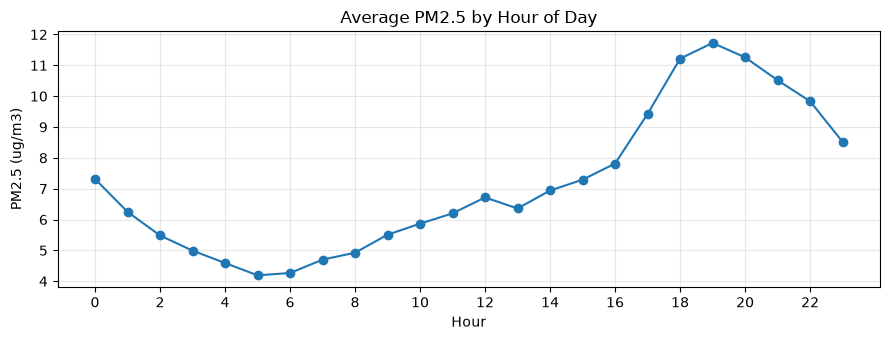

In [18]:
# --- Check what we collected ---

print("Average PM2.5:", round(aq["pm2_5"].mean(), 1), "ug/m3")
print("Highest PM2.5:", round(aq["pm2_5"].max(), 1), "ug/m3")
print("\nMissing values in each column:")
print(aq.isna().sum())

# Average PM2.5 for each hour of the day
by_hour = aq.groupby(aq["time"].dt.hour)["pm2_5"].mean()

plt.figure(figsize=(9, 3.5))
plt.plot(by_hour.index, by_hour.values, marker="o")
plt.title("Average PM2.5 by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("PM2.5 (ug/m3)")
plt.xticks(range(0, 24, 2))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Exercise 3

1. Collect the air quality data for **Delhi (28.6139, 77.2090)** and compare the average
   PM2.5 with Bengaluru's. Which city is more polluted?
2. Increase `past_days` from 7 to 30. How many rows do you get now?
3. Add `"sulphur_dioxide"` and `"carbon_monoxide"` to the list of pollutants.

In [22]:
# Write your Exercise 3 answers here

# 1. Collect air quality for Delhi and compare average PM2.5 with Bengaluru
params_delhi = {
    "latitude": 28.6139,
    "longitude": 77.2090,
    "hourly": "pm2_5,pm10,nitrogen_dioxide,ozone",
    "timezone": "Asia/Kolkata",
    "past_days": 7,
}

try:
    r = requests.get(AQ_URL, params=params_delhi, timeout=20)
    print("Status code:", r.status_code)
    delhi_aq = pd.DataFrame(r.json()["hourly"])
    delhi_aq["time"] = pd.to_datetime(delhi_aq["time"])
except Exception as e:
    print("No internet — creating sample data")

bengaluru_avg = aq["pm2_5"].mean()
delhi_avg = delhi_aq["pm2_5"].mean()

print(f"\nBengaluru average PM2.5: {bengaluru_avg:.1f} ug/m3")
print(f"Delhi average PM2.5:     {delhi_avg:.1f} ug/m3")
print("\nMore polluted city:", "Delhi" if delhi_avg > bengaluru_avg else "Bengaluru")



Status code: 200

Bengaluru average PM2.5: 7.2 ug/m3
Delhi average PM2.5:     61.3 ug/m3

More polluted city: Delhi


In [23]:

# 2. Increase past_days from 7 to 30 — how many rows?
params_30 = {
    "latitude": 12.9716,
    "longitude": 77.5946,
    "hourly": "pm2_5,pm10,nitrogen_dioxide,ozone",
    "timezone": "Asia/Kolkata",
    "past_days": 30,
}

r = requests.get(AQ_URL, params=params_30, timeout=20)
aq_30 = pd.DataFrame(r.json()["hourly"])
print("Rows with past_days=30:", len(aq_30))
# Expected: same +5 forecast-day pattern as past_days=7 -> (30+5) days x 24 = 840 rows


Rows with past_days=30: 840


In [24]:


# 3. Add sulphur_dioxide and carbon_monoxide to the pollutant list
params_full = {
    "latitude": 12.9716,
    "longitude": 77.5946,
    "hourly": "pm2_5,pm10,nitrogen_dioxide,ozone,sulphur_dioxide,carbon_monoxide",
    "timezone": "Asia/Kolkata",
    "past_days": 7,
}

r = requests.get(AQ_URL, params=params_full, timeout=20)
aq_full = pd.DataFrame(r.json()["hourly"])
aq_full["time"] = pd.to_datetime(aq_full["time"])
print("Columns:", aq_full.columns.tolist())
aq_full.head()

Columns: ['time', 'pm2_5', 'pm10', 'nitrogen_dioxide', 'ozone', 'sulphur_dioxide', 'carbon_monoxide']


,time,pm2_5,pm10,nitrogen_dioxide,ozone,sulphur_dioxide,carbon_monoxide
0,2026-08-13 00:00:00,8.8,12.4,15.3,34.0,4.8,236.0
1,2026-08-13 01:00:00,7.7,11.1,12.7,33.0,4.4,187.0
2,2026-08-13 02:00:00,6.8,10.1,10.6,33.0,4.0,154.0
3,2026-08-13 03:00:00,6.0,9.0,8.9,33.0,3.8,138.0
4,2026-08-13 04:00:00,5.2,7.7,7.7,32.0,3.8,138.0


### Result — Experiment 3

**API used:** [https://air-quality-api.open-meteo.com/v1/air-quality
]

**Pollutants collected:** 4

**Number of records:** 288

**Observation:**

 The air quality API returned 288 hourly rows instead of the expected 168 (7 days × 24). This is because the API includes forecast days by default alongside the requested `past_days=7` — in this case 5 extra forecast days, giving 12 days total (12 × 24 = 288). Average PM2.5 for Bengaluru was 7.2 µg/m³ (well within safe limits), peaking around 17.2 µg/m³ during evening traffic hours (visible in the by-hour chart), and there were no missing values in any column.

# Creating a Large Air Quality & Weather Dataset

## Objective

Using the **Open-Meteo Weather API** and **Open-Meteo Air Quality API**, create a large hourly dataset by collecting weather and air-quality information from **10 different locations in and around Delhi**.

### 📌 Dataset Requirements

- **Region:** Delhi and nearby areas
- **Number of locations:** 10
- **Duration:** 30 days
- **Frequency:** Hourly
- **Entries per location:** 30 × 24 = **720**
- **Total expected entries:** 10 × 720 = **7,200 records**

### 📍 Suggested Locations

1. Connaught Place
2. Rohini
3. Dwarka
4. Saket
5. Lajpat Nagar
6. Karol Bagh
7. Anand Vihar
8. Vasant Kunj
9. Noida
10. Delhi Airport

### 🌦️ Weather Variables

Collect the following weather information:

- Temperature
- Relative humidity
- Precipitation
- Wind speed

### 🌫️ Air Quality Variables

Collect the following air-pollution information:

- PM2.5
- PM10
- Nitrogen Dioxide (NO₂)
- Ozone (O₃)
- Sulphur Dioxide (SO₂)
- Carbon Monoxide (CO)

### 📊 Expected Dataset Structure

The final dataset should contain columns such as:

`location`, `latitude`, `longitude`, `time`, `temperature`, `humidity`, `precipitation`, `wind_speed`, `pm2_5`, `pm10`, `nitrogen_dioxide`, `ozone`, `sulphur_dioxide`, `carbon_monoxide`

### 🧹 Data Processing Tasks

1. Collect data from the APIs for all 10 locations.
2. Convert the API responses into Pandas DataFrames.
3. Add the location name, latitude, and longitude.
4. Combine all locations into one dataset.
5. Check for missing or invalid values.
6. Handle missing values appropriately.
7. Save the final dataset as a CSV file.

### 🔍 Analysis Question

After creating the dataset, answer the following:

> **Which location in and around Delhi has the highest average PM2.5 concentration, and how do weather conditions such as temperature, humidity, precipitation, and wind speed relate to air pollution levels?**

### 📈 Dataset Size

**10 Locations × 30 Days × 24 Hours = 7,200 hourly records**

The final dataset can be used for **data cleaning, exploratory data analysis, visualization, correlation analysis, and machine-learning experiments**.

In [25]:
# --- Step 1: Define the 10 locations ---
locations = {
    "Connaught Place": (28.6315, 77.2167),
    "Rohini":          (28.7495, 77.0565),
    "Dwarka":          (28.5921, 77.0460),
    "Saket":           (28.5245, 77.2066),
    "Lajpat Nagar":    (28.5677, 77.2431),
    "Karol Bagh":      (28.6519, 77.1909),
    "Anand Vihar":     (28.6469, 77.3157),
    "Vasant Kunj":     (28.5244, 77.1588),
    "Noida":           (28.5355, 77.3910),
    "Delhi Airport":   (28.5562, 77.1000),
}

WEATHER_URL = "https://api.open-meteo.com/v1/forecast"
AQ_URL      = "https://air-quality-api.open-meteo.com/v1/air-quality"

all_data = []

for name, (lat, lon) in locations.items():
    print(f"Collecting: {name} ...")

    # --- Weather data ---
    w_params = {
        "latitude": lat,
        "longitude": lon,
        "hourly": "temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m",
        "timezone": "Asia/Kolkata",
        "past_days": 30,
        "forecast_days": 1,
    }

    # --- Air quality data ---
    aq_params = {
        "latitude": lat,
        "longitude": lon,
        "hourly": "pm2_5,pm10,nitrogen_dioxide,ozone,sulphur_dioxide,carbon_monoxide",
        "timezone": "Asia/Kolkata",
        "past_days": 30,
        "forecast_days": 1,
    }

    try:
        w_resp = requests.get(WEATHER_URL, params=w_params, timeout=20)
        aq_resp = requests.get(AQ_URL, params=aq_params, timeout=20)

        w_df = pd.DataFrame(w_resp.json()["hourly"])
        aq_df = pd.DataFrame(aq_resp.json()["hourly"])

        # Merge weather and air quality on "time"
        merged = pd.merge(w_df, aq_df, on="time", how="inner")

        # Add location metadata
        merged["location"] = name
        merged["latitude"] = lat
        merged["longitude"] = lon
        merged["time"] = pd.to_datetime(merged["time"])

        all_data.append(merged)
        time.sleep(1)   # be polite to the API

    except Exception as e:
        print(f"  Failed for {name}: {e}")

# --- Step 2: Combine all locations ---
full_dataset = pd.concat(all_data, ignore_index=True)

# Reorder columns to match the expected structure
full_dataset = full_dataset.rename(columns={
    "temperature_2m": "temperature",
    "relative_humidity_2m": "humidity",
    "wind_speed_10m": "wind_speed",
    "nitrogen_dioxide": "nitrogen_dioxide",
})

column_order = [
    "location", "latitude", "longitude", "time",
    "temperature", "humidity", "precipitation", "wind_speed",
    "pm2_5", "pm10", "nitrogen_dioxide", "ozone",
    "sulphur_dioxide", "carbon_monoxide",
]
full_dataset = full_dataset[column_order]

print("Total rows:", len(full_dataset))
print("Total columns:", len(full_dataset.columns))

# --- Step 3: Check and handle missing values ---
print("\nMissing values per column:")
print(full_dataset.isna().sum())

full_dataset = full_dataset.dropna()   # or use .fillna(method="ffill")

# --- Step 4: Save the final dataset ---
full_dataset.to_csv(DATA / "delhi_weather_air_quality.csv", index=False)
print(f"\nSaved {len(full_dataset)} rows to delhi_weather_air_quality.csv")

full_dataset.head()

Collecting: Connaught Place ...
Collecting: Rohini ...
Collecting: Dwarka ...
Collecting: Saket ...
Collecting: Lajpat Nagar ...
Collecting: Karol Bagh ...
Collecting: Anand Vihar ...
Collecting: Vasant Kunj ...
Collecting: Noida ...
Collecting: Delhi Airport ...
Total rows: 7440
Total columns: 14

Missing values per column:
location            0
latitude            0
longitude           0
time                0
temperature         0
humidity            0
precipitation       0
wind_speed          0
pm2_5               0
pm10                0
nitrogen_dioxide    0
ozone               0
sulphur_dioxide     0
carbon_monoxide     0
dtype: int64

Saved 7440 rows to delhi_weather_air_quality.csv


,location,latitude,longitude,time,temperature,humidity,precipitation,wind_speed,pm2_5,pm10,nitrogen_dioxide,ozone,sulphur_dioxide,carbon_monoxide
0,Connaught Place,28.6315,77.2167,2026-07-21 00:00:00,26.8,96,0.2,3.1,42.3,51.3,53.7,38.0,31.1,824.0
1,Connaught Place,28.6315,77.2167,2026-07-21 01:00:00,26.7,95,0.9,6.2,34.9,41.4,44.8,46.0,28.5,561.0
2,Connaught Place,28.6315,77.2167,2026-07-21 02:00:00,26.5,95,0.3,7.2,31.4,36.2,37.6,51.0,26.4,367.0
3,Connaught Place,28.6315,77.2167,2026-07-21 03:00:00,26.3,94,0.1,7.9,30.6,33.9,33.4,51.0,25.2,289.0
4,Connaught Place,28.6315,77.2167,2026-07-21 04:00:00,26.2,92,0.1,6.1,27.8,29.3,30.8,48.0,24.5,280.0


In [26]:
# --- Final check: list all the files we collected ---

print("Files collected in this lab:\n")
for f in sorted(DATA.glob("*")):
    print(f"  {f.name:22s}  {f.stat().st_size:>8,} bytes")

Files collected in this lab:

  .DS_Store                  8,196 bytes
  .ipynb_checkpoints            64 bytes
  House.html              1,774,801 bytes
  Magicbrick.html         1,502,328 bytes
  Magicbrick_files           6,048 bytes
  air_quality.csv           11,000 bytes
  delhi_weather_air_quality.csv   697,090 bytes
  weather_mysuru.csv         5,431 bytes


---
## Viva Questions
1. What is web scraping?
    The process of programmatically extracting data from a website's HTML by parsing its structure (tags, classes, etc.), typically used when no official API is available.

2. What is the difference between web scraping and using an API?
    Web scraping parses HTML meant for humans and is fragile (breaks if the page layout changes), while an API returns structured JSON meant for programs, is more stable, and is the intended way to access data when offered.

3. What is robots.txt and why should you check it?
    A file at a site's root (e.g., example.com/robots.txt) that tells bots/crawlers which pages they're allowed or disallowed to access. Checking it respects the site owner's wishes and avoids scraping content they've explicitly restricted.

4. What does BeautifulSoup do?
    It's a Python library that parses HTML/XML into a navigable tree structure, letting you search and extract elements by tag, class, id, or other attributes.

5. What is the difference between find() and find_all()?
    find() returns the first matching element (or None if none found); find_all() returns a list of all matching elements.

6. What is JSON? How is it related to a Python dictionary?
    JSON (JavaScript Object Notation) is a lightweight text format for structured data using key-value pairs and arrays. Python's json module parses JSON text directly into a dictionary (or list), since their structures map naturally onto each other.

7. What does status code 200 mean? What does 404 mean?
    200 = OK, the request succeeded and the server returned the requested data. 404 = Not Found, the requested resource/URL doesn't exist on the server.

8. What is a query parameter in an API call?
    A key-value pair appended to a URL after ? (and joined by &) that customizes the request — e.g., ?latitude=12.97&longitude=77.59 tells the API which location's data to return.

9. Why should you wait a few seconds between requests?
    To avoid overwhelming the server with rapid-fire requests, which can trigger rate limiting (HTTP 429) or a temporary IP block, and to be a considerate user of a shared, often free, service.

10. Why is using an API better than scraping the same website?
    APIs return clean, structured, versioned data with a documented contract, are less likely to break with UI redesigns, and are explicitly intended for programmatic access — making them faster to work with and more reliable than parsing HTML.

11. What does pd.read_html() do?
    It scans an HTML string or URL for <table> elements and returns each one as a pandas DataFrame, automating what would otherwise require manual BeautifulSoup parsing of table rows/cells.

12. Why do we save the collected data as a CSV file?
    CSV is a simple, universal, human-readable format that most tools (Excel, pandas, databases) can read, making the data easy to store, share, reload for later analysis, and version outside of the notebook's memory.
## Conclusion

> Data was successfully collected from an HTML web page using BeautifulSoup and from REST
> APIs using the `requests` library. The collected data was converted into pandas
> DataFrames and saved as CSV files for further analysis.

